# DenseNet121 - classificação CPRE em 4 classes


In [19]:
# =========================
# 1. Imports e configuração
# =========================

from pathlib import Path
import os
import gc
import random
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import models, transforms

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

# Evita fragmentação da memória CUDA
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(torch.cuda.memory_summary(abbreviated=True))

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Requested memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|--------------

In [20]:
# =========================
# 2. Configuração principal
# =========================

DATA_ROOT = Path('/mounts/mecd-ap-g5/data')
DATASET_DIR = DATA_ROOT / 'MIQR-CC-Dataset'
PROCESSED_IMAGES_DIR = DATASET_DIR / 'processed'
METADATA_PATH = DATASET_DIR / 'metadata.csv'

NOTEBOOK_NAME = 'densenet121_4class_sampler_finetune'
RESULTS_DIR = Path('/mounts/mecd-ap-g5/results') / NOTEBOOK_NAME
MODELS_DIR = Path('/mounts/mecd-ap-g5/models') / NOTEBOOK_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparâmetros
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4

# Treino em duas fases
HEAD_EPOCHS = 8
FINETUNE_EPOCHS = 25
PATIENCE = 6

LR_BACKBONE = 1e-5
LR_HEAD = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
BASELINE_MACRO_F1 = 0.738

PIN_MEMORY = torch.cuda.is_available()
USE_AMP = torch.cuda.is_available()

print('Metadata:', METADATA_PATH)
print('Images:', PROCESSED_IMAGES_DIR)
print('Results:', RESULTS_DIR)
print('Models:', MODELS_DIR)

assert METADATA_PATH.exists(), f"METADATA_PATH não existe: {METADATA_PATH}"
assert PROCESSED_IMAGES_DIR.exists(), f"PROCESSED_IMAGES_DIR não existe: {PROCESSED_IMAGES_DIR}"

Metadata: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/metadata.csv
Images: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/processed
Results: /mounts/mecd-ap-g5/results/densenet121_4class_sampler_finetune
Models: /mounts/mecd-ap-g5/models/densenet121_4class_sampler_finetune


In [21]:
# =========================
# 3. Leitura e limpeza dos metadados
# =========================

df = pd.read_csv(METADATA_PATH)

print("Shape original:", df.shape)
display(df.head())
print("Colunas:", df.columns.tolist())

# Colunas do teu CSV
label_col = "Label"
image_col = "processed_image_path"
patient_col = "patient_id"

assert label_col in df.columns, f"Coluna {label_col} não encontrada."
assert image_col in df.columns, f"Coluna {image_col} não encontrada."
assert patient_col in df.columns, f"Coluna {patient_col} não encontrada."

# Manter apenas imagens marcadas como Keep
if "Keep" in df.columns:
    df = df[df["Keep"].astype(str).str.lower().eq("keep")].copy()

# Remover imagens sem label útil
df = df[~df[label_col].astype(str).str.lower().isin([
    "unlabelled", "unlabeled", "nan", "none", ""
])].copy()

print("Shape após filtro Keep + labels úteis:", df.shape)
display(df[label_col].value_counts())

Shape original: (19317, 12)


,raw_image_path,processed_image_path,patient_id,image_type,sex,birth_date,exam_date,exam_time,age,equipment_model,Label,Keep
0,raw/1_image1.png,processed/1_image1.png,1,S,M,22/08/1952,03/02/2022,11:50:32,69.0,Ziehm Vision RFD,Unlabelled,Keep
1,raw/1_image2.png,processed/1_image2.png,1,S,M,22/08/1952,03/02/2022,11:47:43,69.0,Ziehm Vision RFD,Unlabelled,Keep
2,raw/1_image3.png,processed/1_image3.png,1,S,M,22/08/1952,03/02/2022,12:08:45,69.0,Ziehm Vision RFD,Unlabelled,Keep
3,raw/1_image4.png,processed/1_image4.png,1,S,M,22/08/1952,03/02/2022,11:50:22,69.0,Ziehm Vision RFD,Unlabelled,Keep
4,raw/2_image5.png,processed/2_image5.png,2,S,F,15/08/1925,21/06/2022,20:09:00,96.0,Ziehm Vision RFD,Lithiasis,Discard


Colunas: ['raw_image_path', 'processed_image_path', 'patient_id', 'image_type', 'sex', 'birth_date', 'exam_date', 'exam_time', 'age', 'equipment_model', 'Label', 'Keep']
Shape após filtro Keep + labels úteis: (1568, 12)


Label
Lithiasis              726
Malignant Stricture    329
Normal                 299
Biliary Leaks          151
Benign Stricture        63
Name: count, dtype: int64

In [22]:
# =========================
# 4. Resolver caminhos das imagens
# =========================

def resolve_image_path(x):
    x = str(x)
    p = Path(x)

    # Caminho absoluto
    if p.exists():
        return p

    # Caminho relativo ao dataset
    p2 = DATASET_DIR / x
    if p2.exists():
        return p2

    # Caminho relativo à pasta processed
    p3 = PROCESSED_IMAGES_DIR / Path(x).name
    if p3.exists():
        return p3

    return None

df["image_path"] = df[image_col].apply(resolve_image_path)

existing = df["image_path"].notna().sum()
print(f"Imagens existentes: {existing} / {len(df)}")

if existing < len(df):
    print("Exemplos sem caminho encontrado:")
    display(df[df["image_path"].isna()].head())

df = df[df["image_path"].notna()].copy()
df["image_path"] = df["image_path"].astype(str)

print("Shape final com imagens existentes:", df.shape)
display(df[["image_path", label_col, patient_col]].head())

Imagens existentes: 1568 / 1568
Shape final com imagens existentes: (1568, 13)


,image_path,Label,patient_id
23,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,3
36,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Malignant Stricture,5
50,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,6
65,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Malignant Stricture,9
68,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Malignant Stricture,9


In [23]:
# =========================
# 5. Mapear para 4 classes
# =========================

def map_to_4_classes(label):
    label = str(label).strip()

    if label in ["Benign Stricture", "Malignant Stricture", "Stricture"]:
        return "Stricture"
    elif label in ["Biliary Leaks", "Biliary_Leaks", "Bile Leaks", "Bile leaks"]:
        return "Biliary Leaks"
    elif label in ["Lithiasis", "Stones", "Biliary lithiasis"]:
        return "Lithiasis"
    elif label in ["Normal", "normal"]:
        return "Normal"
    else:
        return None

df["label"] = df[label_col].apply(map_to_4_classes)
df = df[df["label"].notna()].copy()

class_names = ["Biliary Leaks", "Lithiasis", "Stricture", "Normal"]
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["target"] = df["label"].map(class_to_idx)
df[patient_col] = df[patient_col].astype(str)

print("Distribuição final das 4 classes:")
display(df["label"].value_counts())
print("Total:", len(df))

assert set(df["label"].unique()).issubset(set(class_names))
assert df["target"].isna().sum() == 0

Distribuição final das 4 classes:


label
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64

Total: 1568


In [24]:
# =========================
# 6. Split estratificado por paciente
# =========================

def stratified_group_split(data, label_col="target", group_col="patient_id", seed=42):
    data = data.reset_index(drop=True).copy()

    # Primeiro split: 80% train_val, 20% test
    sgkf1 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    train_val_idx, test_idx = next(sgkf1.split(data, y=data[label_col], groups=data[group_col]))

    train_val_df = data.iloc[train_val_idx].reset_index(drop=True)
    test_df = data.iloc[test_idx].reset_index(drop=True)

    # Segundo split: dentro dos 80%, 75% train e 25% val -> global 60/20/20 aprox.
    sgkf2 = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=seed)
    train_idx, val_idx = next(sgkf2.split(train_val_df, y=train_val_df[label_col], groups=train_val_df[group_col]))

    train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
    val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

    return train_df, val_df, test_df

train_df, val_df, test_df = stratified_group_split(
    df,
    label_col="target",
    group_col=patient_col,
    seed=SEED
)

print("Tamanhos:")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nDistribuição train:")
display(train_df["label"].value_counts())
print("\nDistribuição val:")
display(val_df["label"].value_counts())
print("\nDistribuição test:")
display(test_df["label"].value_counts())

# Verificar se não há patient leakage
train_patients = set(train_df[patient_col])
val_patients = set(val_df[patient_col])
test_patients = set(test_df[patient_col])

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

train_df.to_csv(RESULTS_DIR / "train_split.csv", index=False)
val_df.to_csv(RESULTS_DIR / "val_split.csv", index=False)
test_df.to_csv(RESULTS_DIR / "test_split.csv", index=False)

print("Splits guardados em:", RESULTS_DIR)

Tamanhos:
Train: 1021
Val: 309
Test: 238

Distribuição train:


label
Lithiasis        473
Stricture        223
Normal           211
Biliary Leaks    114
Name: count, dtype: int64


Distribuição val:


label
Lithiasis        120
Stricture        117
Normal            54
Biliary Leaks     18
Name: count, dtype: int64


Distribuição test:


label
Lithiasis        133
Stricture         52
Normal            34
Biliary Leaks     19
Name: count, dtype: int64

Splits guardados em: /mounts/mecd-ap-g5/results/densenet121_4class_sampler_finetune


In [25]:
# =========================
# 7. Dataset e transforms
# =========================

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

class ERCPDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        label = int(row["target"])

        if self.transform is not None:
            img = self.transform(img)

        return img, label

train_dataset = ERCPDataset(train_df, transform=train_tfms)
val_dataset = ERCPDataset(val_df, transform=eval_tfms)
test_dataset = ERCPDataset(test_df, transform=eval_tfms)

In [26]:
# =========================
# 8. DataLoaders com WeightedRandomSampler
# =========================

# Sampler para equilibrar batches.
# Nota: aqui NÃO usamos class weights na loss, para não duplicar a compensação.
class_counts = train_df["target"].value_counts().sort_index()
class_weights_np = len(train_df) / (len(class_names) * class_counts.values)

print("Class counts:")
display(class_counts)
print("Sampler class weights:", class_weights_np)

sample_weights = train_df["target"].map(lambda x: class_weights_np[int(x)]).values

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Batches train:", len(train_loader))
print("Batches val:", len(val_loader))
print("Batches test:", len(test_loader))

Class counts:


target
0    114
1    473
2    223
3    211
Name: count, dtype: int64

Sampler class weights: [2.23903509 0.53964059 1.14461883 1.20971564]
Batches train: 64
Batches val: 20
Batches test: 15


In [34]:
# =========================
# 9. Modelo DenseNet121
# =========================

def create_densenet121(num_classes=4):
    weights = models.DenseNet121_Weights.IMAGENET1K_V1
    model = models.densenet121(weights=weights)

    in_features = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )

    return model

model = create_densenet121(num_classes=len(class_names)).to(device)

print(model.classifier)

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_params(model)
print(f"Parâmetros totais: {total:,}")
print(f"Parâmetros treináveis: {trainable:,}")

Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1024, out_features=512, bias=True)
  (2): ReLU(inplace=True)
  (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=512, out_features=4, bias=True)
)
Parâmetros totais: 7,481,732
Parâmetros treináveis: 7,481,732


In [35]:
# =========================
# 10. Funções de treino e avaliação
# =========================

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

def clean_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    total_loss = 0.0
    n = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        bs = labels.size(0)
        total_loss += loss.item() * bs
        n += bs

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return {
        "loss": total_loss / max(n, 1),
        "y_true": np.array(all_labels),
        "y_pred": np.array(all_preds),
        "y_prob": np.array(all_probs)
    }

def compute_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    if y_prob is not None:
        y_onehot = np.eye(len(class_names))[y_true]
        try:
            metrics["roc_auc_macro_ovr"] = roc_auc_score(
                y_onehot, y_prob, average="macro", multi_class="ovr"
            )
        except Exception:
            metrics["roc_auc_macro_ovr"] = np.nan

        try:
            metrics["pr_auc_macro"] = average_precision_score(
                y_onehot, y_prob, average="macro"
            )
        except Exception:
            metrics["pr_auc_macro"] = np.nan

    return metrics

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    n = 0

    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)

        bs = labels.size(0)
        running_loss += loss.item() * bs
        n += bs

        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    train_loss = running_loss / max(n, 1)
    train_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return train_loss, train_macro_f1

def run_training_phase(model, train_loader, val_loader, optimizer, scheduler, epochs, phase_name, patience=PATIENCE):
    best_val_f1 = -1
    best_path = MODELS_DIR / f"best_{phase_name}.pt"
    history = []
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer)

        val_out = predict_loader(model, val_loader)
        val_metrics = compute_metrics(val_out["y_true"], val_out["y_pred"], val_out["y_prob"])

        if scheduler is not None:
            scheduler.step(val_metrics["macro_f1"])

        row = {
            "phase": phase_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_macro_f1": train_f1,
            "val_loss": val_out["loss"],
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }
        history.append(row)

        print(
            f"[{phase_name}] Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_f1={train_f1:.4f} | "
            f"val_loss={val_out['loss']:.4f} val_f1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            bad_epochs = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "class_names": class_names,
                "class_to_idx": class_to_idx,
                "phase": phase_name,
                "best_val_macro_f1": best_val_f1,
                "config": {
                    "IMG_SIZE": IMG_SIZE,
                    "BATCH_SIZE": BATCH_SIZE,
                    "LR_BACKBONE": LR_BACKBONE,
                    "LR_HEAD": LR_HEAD,
                    "WEIGHT_DECAY": WEIGHT_DECAY,
                    "LABEL_SMOOTHING": LABEL_SMOOTHING,
                    "BASELINE_MACRO_F1": BASELINE_MACRO_F1,
                }
            }, best_path)
            print("  -> Novo melhor modelo guardado:", best_path)
        else:
            bad_epochs += 1

        pd.DataFrame(history).to_csv(RESULTS_DIR / f"history_{phase_name}.csv", index=False)

        if bad_epochs >= patience:
            print(f"Early stopping em {phase_name}.")
            break

        clean_cuda()

    return best_path, pd.DataFrame(history)

In [11]:
!nvidia-smi

Mon May 25 22:10:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    Off |   00000000:41:00.0 Off |                  Off |
| 36%   63C    P2             77W /  300W |   48484MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [36]:
# =========================
# 11. Fase 1 — treinar apenas a cabeça
# =========================

# Congelar backbone
for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

total, trainable = count_params(model)
print(f"Parâmetros treináveis na fase head: {trainable:,} / {total:,}")

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

best_head_path, hist_head = run_training_phase(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs=HEAD_EPOCHS,
    phase_name="head",
    patience=PATIENCE
)

Parâmetros treináveis na fase head: 527,876 / 7,481,732
[head] Epoch 01/8 | train_loss=1.4554 train_f1=0.3027 | val_loss=1.3705 val_f1=0.2699
  -> Novo melhor modelo guardado: /mounts/mecd-ap-g5/models/densenet121_4class_sampler_finetune/best_head.pt
[head] Epoch 02/8 | train_loss=1.3255 train_f1=0.4049 | val_loss=1.5075 val_f1=0.1998
[head] Epoch 03/8 | train_loss=1.2674 train_f1=0.4206 | val_loss=1.4660 val_f1=0.2493
[head] Epoch 04/8 | train_loss=1.1947 train_f1=0.4655 | val_loss=1.3795 val_f1=0.3004
  -> Novo melhor modelo guardado: /mounts/mecd-ap-g5/models/densenet121_4class_sampler_finetune/best_head.pt
[head] Epoch 05/8 | train_loss=1.1606 train_f1=0.5043 | val_loss=1.3428 val_f1=0.2541
[head] Epoch 06/8 | train_loss=1.2227 train_f1=0.4828 | val_loss=1.3826 val_f1=0.2534
[head] Epoch 07/8 | train_loss=1.1561 train_f1=0.5017 | val_loss=1.3433 val_f1=0.2877
[head] Epoch 08/8 | train_loss=1.1578 train_f1=0.5138 | val_loss=1.3052 val_f1=0.3100
  -> Novo melhor modelo guardado: /mou

In [40]:
# =========================
# 12. Fase 2 — fine-tuning parcial
# =========================

# Carregar melhor modelo da fase head
checkpoint = torch.load(best_head_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

# Congelar tudo primeiro
for param in model.features.parameters():
    param.requires_grad = False

# Descongelar últimos blocos do DenseNet
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.features.norm5.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

total, trainable = count_params(model)
print(f"Parâmetros treináveis no fine-tuning: {trainable:,} / {total:,}")

optimizer = torch.optim.AdamW([
    {"params": model.features.denseblock4.parameters(), "lr": LR_BACKBONE},
    {"params": model.features.norm5.parameters(), "lr": LR_BACKBONE},
    {"params": model.classifier.parameters(), "lr": LR_HEAD},
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

best_ft_path, hist_ft = run_training_phase(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs=FINETUNE_EPOCHS,
    phase_name="finetune",
    patience=PATIENCE
)

# Guardar histórico completo
history = pd.concat([hist_head, hist_ft], ignore_index=True)
history.to_csv(RESULTS_DIR / "training_history_full.csv", index=False)
display(history.tail())

Parâmetros treináveis no fine-tuning: 2,688,004 / 7,481,732
[finetune] Epoch 01/25 | train_loss=1.1780 train_f1=0.4931 | val_loss=1.4409 val_f1=0.2420
  -> Novo melhor modelo guardado: /mounts/mecd-ap-g5/models/densenet121_4class_sampler_finetune/best_finetune.pt
[finetune] Epoch 02/25 | train_loss=1.1301 train_f1=0.5278 | val_loss=1.3643 val_f1=0.2814
  -> Novo melhor modelo guardado: /mounts/mecd-ap-g5/models/densenet121_4class_sampler_finetune/best_finetune.pt
[finetune] Epoch 03/25 | train_loss=1.1391 train_f1=0.5332 | val_loss=1.3666 val_f1=0.2669
[finetune] Epoch 04/25 | train_loss=1.0623 train_f1=0.5731 | val_loss=1.3853 val_f1=0.2631
[finetune] Epoch 05/25 | train_loss=1.0457 train_f1=0.5787 | val_loss=1.3335 val_f1=0.2892
  -> Novo melhor modelo guardado: /mounts/mecd-ap-g5/models/densenet121_4class_sampler_finetune/best_finetune.pt
[finetune] Epoch 06/25 | train_loss=1.0478 train_f1=0.5820 | val_loss=1.3623 val_f1=0.2741
[finetune] Epoch 07/25 | train_loss=1.0371 train_f1=0.5

,phase,epoch,train_loss,train_macro_f1,val_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_roc_auc_macro_ovr,val_pr_auc_macro
21,finetune,14,0.922681,0.632982,1.333867,0.385113,0.352974,0.333109,0.388736,0.622575,0.318940
22,finetune,15,0.895968,0.644984,1.324547,0.407767,0.356179,0.346605,0.411240,0.636014,0.327174
23,finetune,16,0.884015,0.677371,1.294330,0.378641,0.321172,0.315953,0.379553,0.633614,0.326390
24,finetune,17,0.847881,0.676833,1.328473,0.401294,0.376051,0.360813,0.405783,0.637559,0.330288
25,finetune,18,0.869877,0.656690,1.297352,0.411003,0.341684,0.340033,0.411606,0.642074,0.332827


In [41]:
# =========================
# 13. Avaliação final no teste
# =========================

# Carregar melhor modelo de fine-tuning
checkpoint = torch.load(best_ft_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

test_out = predict_loader(model, test_loader)
test_metrics = compute_metrics(test_out["y_true"], test_out["y_pred"], test_out["y_prob"])

print("Métricas no teste:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

print(f"\nBaseline macro F1: {BASELINE_MACRO_F1:.4f}")
print(f"Diferença para baseline: {test_metrics['macro_f1'] - BASELINE_MACRO_F1:.4f}")

report = classification_report(
    test_out["y_true"],
    test_out["y_pred"],
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).T
display(report_df)

report_df.to_csv(RESULTS_DIR / "classification_report_test.csv")

metrics_path = RESULTS_DIR / "test_metrics.json"
with open(metrics_path, "w") as f:
    json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)

print("Relatório guardado em:", RESULTS_DIR)

Métricas no teste:
accuracy: 0.4370
balanced_accuracy: 0.3393
macro_f1: 0.3372
weighted_f1: 0.4552
roc_auc_macro_ovr: 0.6498
pr_auc_macro: 0.3685

Baseline macro F1: 0.7380
Diferença para baseline: -0.4008


,precision,recall,f1-score,support
Biliary Leaks,0.214286,0.157895,0.181818,19.000000
Lithiasis,0.646018,0.548872,0.593496,133.000000
Stricture,0.395349,0.326923,0.357895,52.000000
Normal,0.161765,0.323529,0.215686,34.000000
accuracy,0.436975,0.436975,0.436975,0.436975
macro avg,0.354354,0.339305,0.337224,238.000000
weighted avg,0.487605,0.436975,0.455182,238.000000


Relatório guardado em: /mounts/mecd-ap-g5/results/densenet121_4class_sampler_finetune


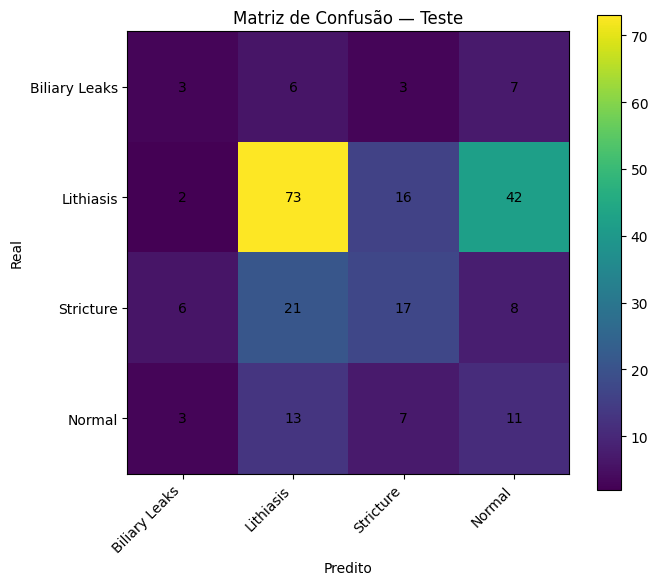

In [42]:
# =========================
# 14. Matriz de confusão
# =========================

cm = confusion_matrix(test_out["y_true"], test_out["y_pred"], labels=list(range(len(class_names))))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)

ax.set_title("Matriz de Confusão — Teste")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix_test.png", dpi=200)
plt.show()

pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(RESULTS_DIR / "confusion_matrix_test.csv")

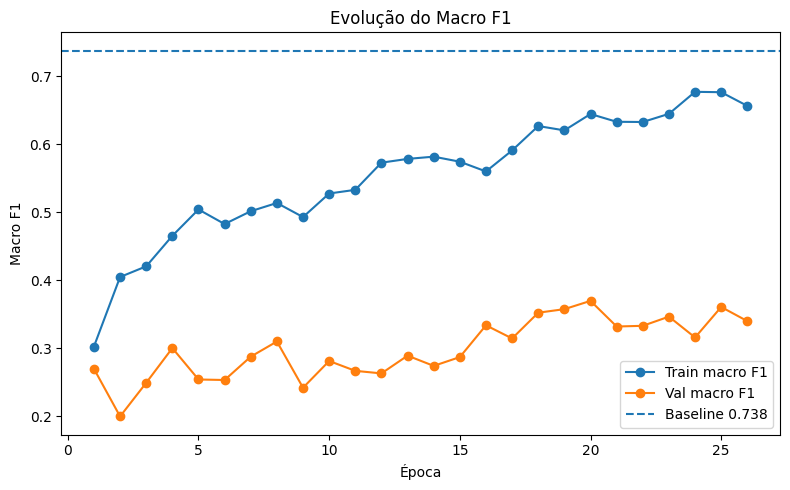

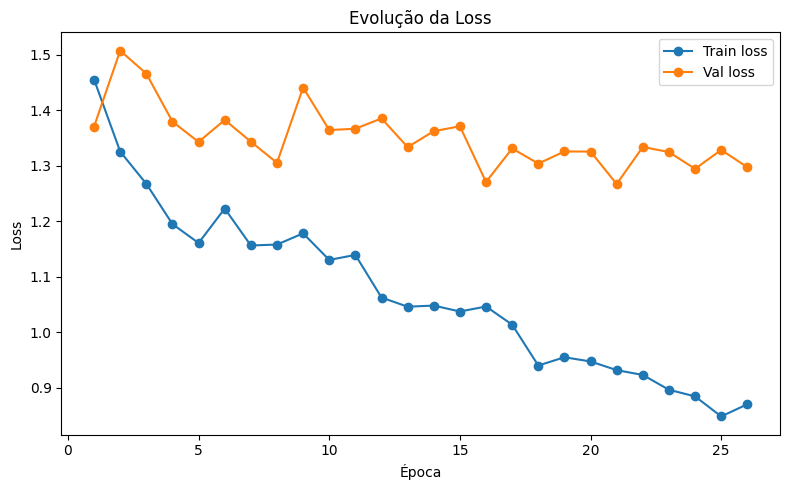

In [43]:
# =========================
# 15. Curvas de treino
# =========================

history = pd.read_csv(RESULTS_DIR / "training_history_full.csv")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.index + 1, history["train_macro_f1"], marker="o", label="Train macro F1")
ax.plot(history.index + 1, history["val_macro_f1"], marker="o", label="Val macro F1")
ax.axhline(BASELINE_MACRO_F1, linestyle="--", label=f"Baseline {BASELINE_MACRO_F1}")
ax.set_title("Evolução do Macro F1")
ax.set_xlabel("Época")
ax.set_ylabel("Macro F1")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_macro_f1.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.index + 1, history["train_loss"], marker="o", label="Train loss")
ax.plot(history.index + 1, history["val_loss"], marker="o", label="Val loss")
ax.set_title("Evolução da Loss")
ax.set_xlabel("Época")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_loss.png", dpi=200)
plt.show()

In [46]:
# =========================
# Corrigir ReLU inplace para Grad-CAM
# =========================

import torch.nn as nn

def replace_inplace_relu(module):
    for name, child in module.named_children():
        if isinstance(child, nn.ReLU):
            setattr(module, name, nn.ReLU(inplace=False))
        else:
            replace_inplace_relu(child)

replace_inplace_relu(model)

print("ReLU inplace desativados para Grad-CAM.")

ReLU inplace desativados para Grad-CAM.


In [47]:
# =========================
# Grad-CAM corrigido para DenseNet
# =========================

import torch
import torch.nn.functional as F
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = self.target_layer.register_forward_hook(self.save_activation)
        self.backward_handle = self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        # clone evita erro com views/inplace
        self.activations = output.detach().clone()

    def save_gradient(self, module, grad_input, grad_output):
        # clone evita erro com views/inplace
        self.gradients = grad_output[0].detach().clone()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        x = x.requires_grad_(True)

        logits = self.model(x)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        score = logits[:, class_idx].sum()
        score.backward(retain_graph=False)

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1)

        cam = F.relu(cam)
        cam = F.interpolate(
            cam.unsqueeze(1),
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False
        ).squeeze(1)

        cam = cam[0].detach().cpu().numpy()

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, logits.detach()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

In [48]:
# =========================
# 17. Guardar modelo final completo
# =========================

final_model_path = MODELS_DIR / "densenet121_4class_final.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "config": {
        "DATASET_DIR": str(DATASET_DIR),
        "PROCESSED_IMAGES_DIR": str(PROCESSED_IMAGES_DIR),
        "METADATA_PATH": str(METADATA_PATH),
        "IMG_SIZE": IMG_SIZE,
        "BATCH_SIZE": BATCH_SIZE,
        "HEAD_EPOCHS": HEAD_EPOCHS,
        "FINETUNE_EPOCHS": FINETUNE_EPOCHS,
        "LR_BACKBONE": LR_BACKBONE,
        "LR_HEAD": LR_HEAD,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "LABEL_SMOOTHING": LABEL_SMOOTHING,
        "BASELINE_MACRO_F1": BASELINE_MACRO_F1,
    }
}, final_model_path)

print("Modelo final guardado em:", final_model_path)
print("Resultados guardados em:", RESULTS_DIR)

Modelo final guardado em: /mounts/mecd-ap-g5/models/densenet121_4class_sampler_finetune/densenet121_4class_final.pt
Resultados guardados em: /mounts/mecd-ap-g5/results/densenet121_4class_sampler_finetune
